# K-Means Clustering

## Overview

K-means partitions n observations into k clusters by iteratively assigning points to the nearest centroid and recomputing centroids until convergence. It minimises within-cluster sum of squares (WCSS / inertia).

**Assumptions and limitations:**
- Clusters are roughly spherical and similarly sized
- Sensitive to outliers (centroid pulled toward extremes)
- Requires specifying k in advance
- Distances are Euclidean — features must be on the same scale

**Choosing k:** elbow plot (inertia), silhouette score, gap statistic.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)
# Simulate 4 ecological site clusters
centers = [(50,6.5),(200,7.2),(350,7.8),(150,6.9)]
X_list = []
for cx, cy in centers:
    n = rng.integers(55, 75)
    X_list.append(np.column_stack([
        rng.normal(cx, 30, n),
        rng.normal(cy, 0.25, n),
        rng.gamma(2+rng.uniform(0,1), 1.5, n),
        rng.normal(7+rng.uniform(-1,1), 0.8, n)
    ]))
X = np.vstack(X_list)
feat_names = ["elevation","ph","nitrate","phosphorus"]
print(f"Dataset: {X.shape[0]} sites, {X.shape[1]} features")

Dataset: 268 sites, 4 features


---
## Standardise and Fit

In [2]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

km = KMeans(n_clusters=4, n_init=20, random_state=42)
labels = km.fit_predict(X_sc)
print(f"Inertia: {km.inertia_:.2f}")
print(f"Silhouette score: {silhouette_score(X_sc, labels):.3f}")
# Cluster profiles
df = pd.DataFrame(X, columns=feat_names)
df["cluster"] = labels
print("\nCluster means (original scale):")
print(df.groupby("cluster")[feat_names].mean().round(2))

Inertia: 438.53
Silhouette score: 0.316

Cluster means (original scale):
         elevation    ph  nitrate  phosphorus
cluster                                      
0           188.36  7.13     7.76        6.75
1           324.62  7.75     3.53        6.40
2            85.45  6.57     3.29        6.08
3           159.01  6.99     2.72        7.83


---
## Choosing k: Elbow and Silhouette

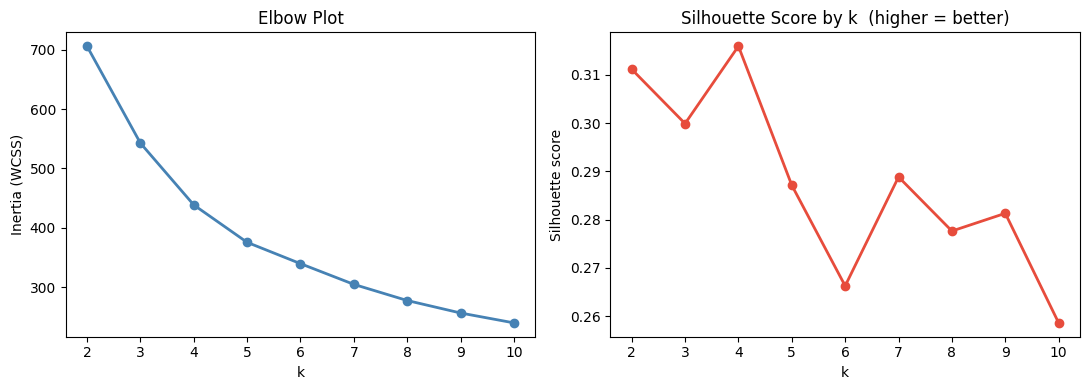

Best silhouette at k=4


In [3]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_sc)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X_sc, km_k.labels_))

fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(ks, inertias, "o-", color="steelblue", lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Plot")
axes[1].plot(ks, sils, "o-", color="#e74c3c", lw=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score by k  (higher = better)")
plt.tight_layout(); plt.show()
print(f"Best silhouette at k={ks[np.argmax(sils)]}")

---
## Silhouette Plot

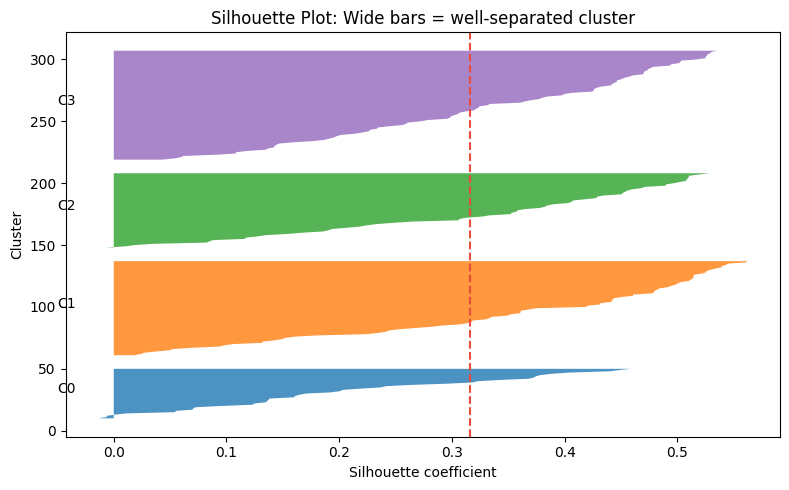

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
sil_vals = silhouette_samples(X_sc, labels)
colors = plt.cm.tab10(np.linspace(0,0.4,4))
y_lower = 10
for k in range(4):
    vals = np.sort(sil_vals[labels==k])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[k], alpha=0.8)
    ax.text(-0.05, y_lower + len(vals)/2, f"C{k}")
    y_lower = y_upper + 10
ax.axvline(silhouette_score(X_sc, labels), color="#e74c3c", lw=1.5, linestyle="--")
ax.set_xlabel("Silhouette coefficient"); ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot: Wide bars = well-separated cluster")
plt.tight_layout(); plt.show()

---
## PCA Visualisation of Clusters

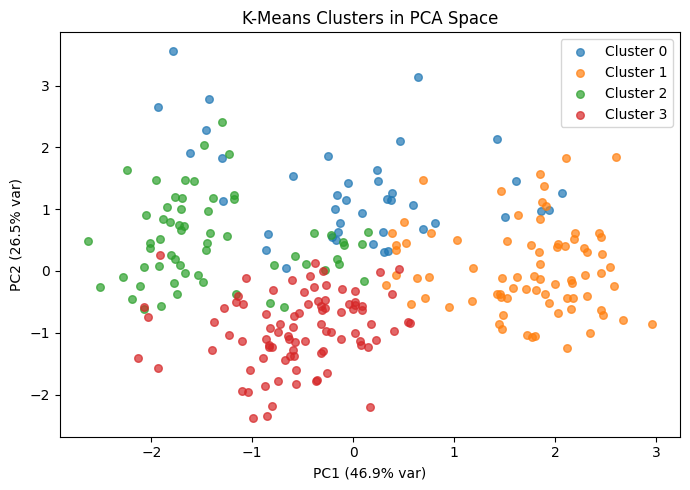

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
var_exp = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7,5))
for k in range(4):
    mask = labels == k
    ax.scatter(X_pca[mask,0], X_pca[mask,1], s=30, alpha=0.7, label=f"Cluster {k}")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} var)")
ax.set_title("K-Means Clusters in PCA Space")
ax.legend(); plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Not standardising features before k-means**  
K-means uses Euclidean distance. A feature with range 0–400 will dominate distance calculations over one with range 6.5–8.0. Always apply `StandardScaler` before fitting. Fit the scaler on training/full data once and apply consistently.

**2. Running k-means once with a single random initialisation**  
K-means is sensitive to initialisation. A single run may converge to a local minimum. Always set `n_init=20` (or more) to run from multiple random starts and keep the best result.

**3. Choosing k from the elbow plot alone**  
The elbow is often ambiguous — the curve may be smooth with no clear kink. Always combine the elbow plot with silhouette scores (and the gap statistic for formal selection) before deciding on k.

**4. Interpreting cluster labels as stable across runs**  
K-means label assignments are arbitrary — cluster 0 in one run may correspond to cluster 3 in another. Labels are not comparable across separate `fit()` calls. Use `predict()` on the same fitted model for new data.

**5. Using k-means when clusters are non-spherical or have very different densities**  
K-means assumes roughly equal-sized, spherical clusters. For elongated, irregular, or density-varying clusters use DBSCAN or Gaussian Mixture Models instead.

---
*python_methods_library - Samantha McGarrigle*